In [1]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn openpyxl

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

sns.set(style="whitegrid", context="talk")
np.random.seed(42)

In [3]:
n = 220

X = pd.DataFrame({
    "PIVC": np.random.normal(0.60, 0.12, n),
    "TPJ": np.random.normal(0.55, 0.11, n),
    "Hippocampus": np.random.normal(0.64, 0.10, n),
    "Parietal": np.random.normal(0.57, 0.09, n),
    "Insula": np.random.normal(0.50, 0.10, n),
    "Cerebellum": np.random.normal(0.47, 0.11, n)
})

y = (
    30
    + X["Hippocampus"] * 24
    + X["PIVC"] * 17
    + X["TPJ"] * 11
    + np.random.normal(0, 5, n)
)

In [4]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Linear": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.05))
    ]),
    "RandomForest": RandomForestRegressor(
        n_estimators=250,
        random_state=42
    )
}

rows = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="r2"
    )

    rows.append([
        name,
        scores.mean(),
        scores.std()
    ])

results = pd.DataFrame(
    rows,
    columns=["model", "mean_r2", "std_r2"]
).sort_values("mean_r2", ascending=False)

results

,model,mean_r2,std_r2
2,Lasso,0.247546,0.126072
1,Ridge,0.247199,0.132199
0,Linear,0.246598,0.133932
3,RandomForest,0.141220,0.089382


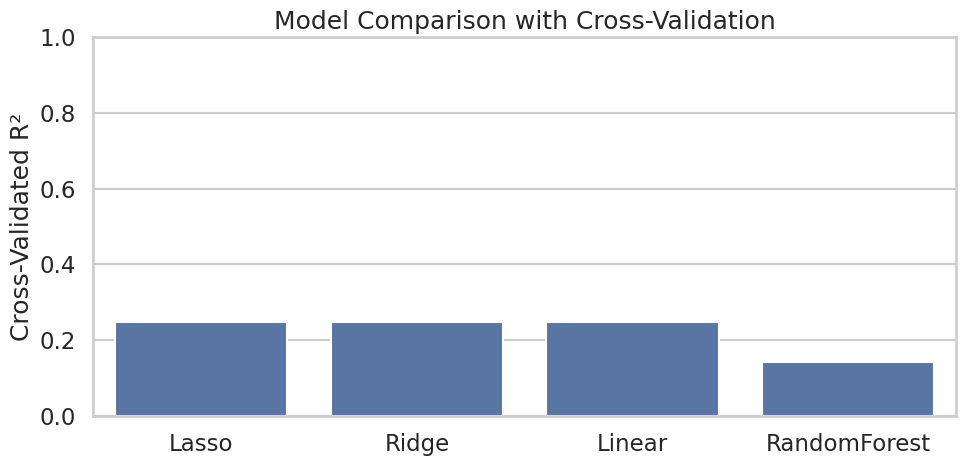

In [5]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results,
    x="model",
    y="mean_r2"
)

plt.ylim(0, 1)
plt.xlabel("")
plt.ylabel("Cross-Validated R²")
plt.title("Model Comparison with Cross-Validation")
plt.tight_layout()
plt.savefig("figures/03_model_comparison.png", dpi=300)
plt.show()

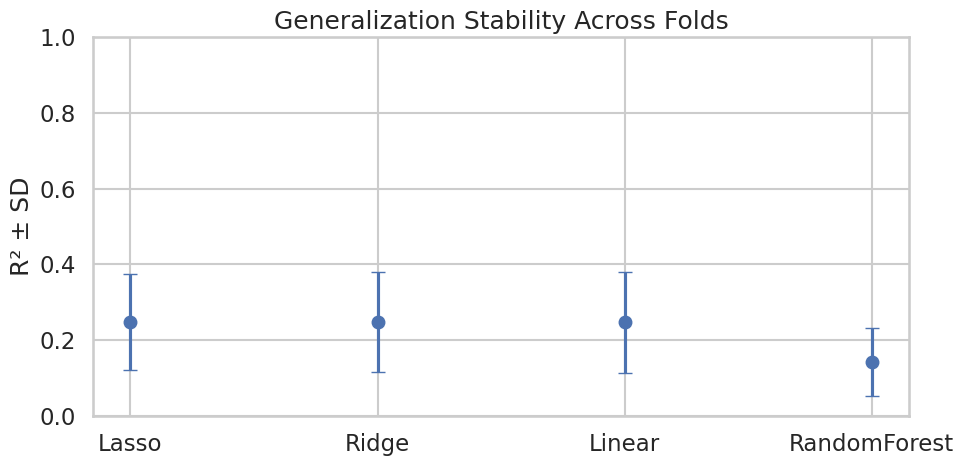

In [6]:
plt.figure(figsize=(10,5))

plt.errorbar(
    x=results["model"],
    y=results["mean_r2"],
    yerr=results["std_r2"],
    fmt="o",
    capsize=5
)

plt.ylim(0, 1)
plt.xlabel("")
plt.ylabel("R² ± SD")
plt.title("Generalization Stability Across Folds")
plt.tight_layout()
plt.savefig("figures/03_generalization_stability.png", dpi=300)
plt.show()

In [7]:
results.to_csv("outputs/03_cross_validation_results.csv", index=False)

results

,model,mean_r2,std_r2
2,Lasso,0.247546,0.126072
1,Ridge,0.247199,0.132199
0,Linear,0.246598,0.133932
3,RandomForest,0.141220,0.089382
